In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from skimage.exposure import equalize_adapthist
from skimage.filters import gaussian as sk_gaussian
from scipy.ndimage import uniform_filter, gaussian_filter
from scipy.stats import pearsonr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')



speckles = np.load('/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/speckle.npy')

In [2]:
# Fast Fourier Transform version of the vortex function
def myfft2(A): 
    return np.fft.fftshift(np.fft.fft2(np.fft.fftshift(A)))


def generate_vortex_map(f, A, m, dim=64, xmax=10, flambda=80):
    """
    Applies a vortex phase of charge 'm' to a batch of images 'A'.
    
    Parameters:
    A (ndarray): Input image batch of shape [num_images, dim, dim]
    m (int): Topological charge (1, 2, 3, etc.)
    dim (int): Pixel resolution of the grid
    xmax (float): Physical limit of the f-plane
    flambda (float): Lens parameter
    
    Returns:
    ndarray: Processed and normalized images of shape [num_images, dim, dim]
    """
    # 1. Setup Coordinates
    dx = 2 * xmax / dim
    x = np.linspace(-xmax, xmax - dx, dim)
    X, Y = np.meshgrid(x, x)
    R2 = (X**2 + Y**2)
    T = np.arctan2(Y, X)

    # 2. Create the LG Mask (Lens + Vortex Phase)
    Lens = np.exp(-1j * R2 / (flambda / 10))
    Vortex = np.exp(1j * m * T)
    LG_mask = Lens * Vortex

    # 3. Process the Batch
    num_images = A.shape[0]
    out = np.zeros_like(A, dtype=np.float64)
    
    for i in range(num_images):
        # Apply phase modulation and distillation 
        # (Assumes wavelet_distillation is defined globally)
        phase_mod = np.exp(1j * A[i] * np.pi * 2)
        distilled = f(phase_mod * LG_mask)
        
        # Calculate Magnitude
        A_mag = np.abs(distilled)
        
        # Normalize to [-1, 1] for NN compatibility
        a_min = np.amin(A_mag)
        a_diff = np.amax(A_mag) - a_min
        
        if a_diff != 0:
            out[i] = (A_mag - a_min) / a_diff * 2 - 1
        else:
            out[i] = A_mag - a_min

    return out

In [3]:
import torch
import torch.nn as nn

class base_model(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc = nn.Linear(dim**2, dim**2, bias=False) # Linear Activation
        self.criterion = nn.MSELoss()
        self.optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)

    def forward(self, x):
        return self.fc(x)

DIM = 64
model = base_model(DIM)

# Generate the DFT of the speckles_masked
X = generate_vortex_map(myfft2, speckles, m=1)

X_train = X.reshape(X.shape[0], -1)
Y_train = speckles.reshape(speckles.shape[0], -1)

# Convert to PyTorch Tensor
X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)

# Training Loop
dataset = torch.utils.data.TensorDataset(X_train, Y_train)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)



In [ ]:
epochs = 500
model.train()

for epoch in range(epochs):
    total_loss = 0.0
    for batch_x, batch_y in dataloader:
        model.optimizer.zero_grad()
        preds = model(batch_x)
        loss = model.criterion(preds, batch_y)
        loss.backward()
        model.optimizer.step()
        total_loss += loss.item()
        
    print(f'{epoch}/{epochs} done')
    

In [ ]:
torch.save(model.state_dict(), '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/speckle_model_weights.pth')

In [4]:
model.load_state_dict(torch.load('/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/speckle_model_weights.pth'))

<All keys matched successfully>

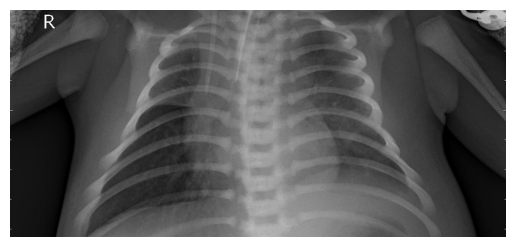

In [16]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/test/PNEUMONIA/person81_bacteria_396.jpeg')


plt.imshow(img)
plt.axis('off')
plt.show()

In [11]:
DIM         = 64
NUM_CLASSES = 2
TRAIN_DIR   = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/train'
TEST_DIR    = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/test'

def apply_smooth_region_filter(image, window=9):
    mean_sq        = uniform_filter(image**2, size=window)
    sq_mean        = uniform_filter(image,    size=window)**2
    local_std      = np.sqrt(np.clip(mean_sq - sq_mean, 0, None)).astype(np.float32)
    s_rng          = local_std.max() - local_std.min()
    local_std_norm = (local_std - local_std.min()) / (s_rng + 1e-8)
    smooth_mask    = gaussian_filter(1.0 - local_std_norm, sigma=1.0)
    filtered       = image * smooth_mask
    f_rng          = filtered.max() - filtered.min()
    return ((filtered - filtered.min()) / (f_rng + 1e-8)).astype(np.float32)


def norm_batch(X):
    mn = X.min(axis=(1,2), keepdims=True)
    mx = X.max(axis=(1,2), keepdims=True)
    return (X - mn) / (mx - mn + 1e-8)


def to_gray(images_rgb, dim=DIM):
    out = np.empty((len(images_rgb), dim, dim), dtype=np.float32)
    for i, img in enumerate(images_rgb):
        gray   = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
        out[i] = gray / 255.0
    return out


def preprocess_xray(img, dim=DIM, window=9):
    img  = equalize_adapthist(img, clip_limit=0.03).astype(np.float32)
    h, w = img.shape
    pad_h = int(h * 0.10); pad_w = int(w * 0.08)
    img   = img[pad_h:h-pad_h, pad_w:w-pad_w]
    img   = cv2.resize(img, (dim, dim), interpolation=cv2.INTER_AREA)
    img   = sk_gaussian(img, sigma=0.5).astype(np.float32)
    if img.max() > 1e-8:
        img = img / img.max()
    img   = apply_smooth_region_filter(img, window=window)
    return img

Train: 100%|██████████| 1/1 [00:00<00:00, 419.05it/s]


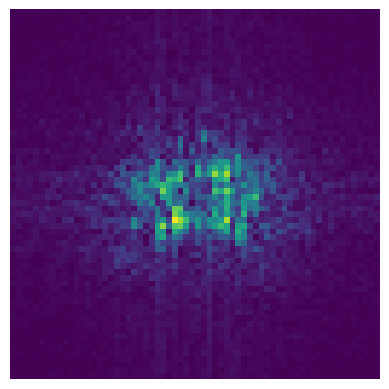

In [17]:
img = cv2.resize(img, (64, 64))
img = np.expand_dims(img, axis=0)
img = to_gray(img)

img_processed = np.zeros((len(img), DIM, DIM), dtype=np.float32)

for i in tqdm(range(len(img)), desc='Train'):
    img_processed[i] = preprocess_xray(img[i])

img = img_processed
del img_processed

img_transformed = generate_vortex_map(myfft2, img, m=1)
img = np.squeeze(img_transformed, axis=0)

plt.imshow(img)
plt.axis('off')
plt.show()

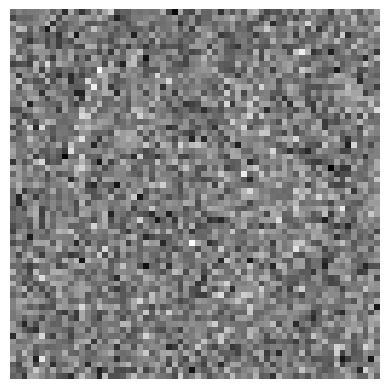

In [18]:
img_flat = torch.tensor(img.flatten(), dtype=torch.float32).unsqueeze(0)

model.eval()

with torch.no_grad():
    output = model(img_flat)

output_img = output.squeeze(0).numpy().reshape(DIM, DIM)

plt.imshow(output_img, cmap='gray')
plt.axis('off')
plt.show()